## Experiment 04

## 1. Experiment Settings
- Sample size (n): 5000
- X1 dimension (d): 10
- X2 dimension (p): 500
- X1 and X2 are correlated.
- Linear relationship between predictor (X1 only) and response (Y).
- Data were generated randomly 5 times to get 5 results from each model for analyzation.

In [1]:
import sys
sys.path.append("../src")

from generate_predictors import generate_predictors
from sklearn.model_selection import train_test_split
from correlation import introduce_correlation

from models.lasso import tune_lasso
from models.lasso import fit_lasso

from models.ridge import tune_ridge
from models.ridge import fit_ridge

from models.random_forest import tune_random_forest
from models.random_forest import fit_random_forest

from models.neural_network import tune_neural_network
from models.neural_network import fit_neural_network

import numpy as np

## 2. Simulation

### Data Generation 1

In [ ]:
np.random.seed(32)
# Configuration for predictors
X1_CONFIG = {
    "size": 5000,
    "dimension": 10,
    "variable_type": "continuous",
    "distribution": "normal",
    "distribution_params": {
        "mean": 0,
        "std": 1
    }
}

X2_CONFIG = {
    "size": 5000,
    "dimension": 500,
    "variable_type": "continuous",
    "distribution": "normal",
    "distribution_params": {
        "mean": 2,
        "std": 5
    }
}

# Generate X1
x1 = generate_predictors(X1_CONFIG)

# Generate X2
x2 = generate_predictors(X2_CONFIG)

# Generate Correlation
corr_config = {
            "method": "linear",
            "strength": 0.3,
            "random_state": 32
        }

X1, X2 = introduce_correlation(x1, x2, corr_config)

 # Generate noise
noise = np.random.normal(
    0,
    1,
    X1.shape[0]
    )
    

# Generate Y
Y = (
    3.0 * X1[:,0]
    -2.0 * X1[:,1]
    +1.5 * X1[:,2]
    -0.8 * X1[:,3]
    +noise
    )

    
# Combine the feature matrices
X = np.hstack((X1, X2))

# Split the data into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=32
    )

### Model Tuning

In [3]:
tuning_models = {
    "Lasso": (
        tune_lasso,
        {
            "alphas": [0.001, 0.01, 0.1, 1, 10]
        }
    ),
    "Ridge": (
        tune_ridge,
        {
            "alphas": [0.001, 0.01, 0.1, 1, 10, 100]
        }
    ),
    "Random Forest": (
        tune_random_forest,
        {
            "param_grid": {
            "n_estimators": [100],
            "max_depth": [10, 20, None],
            "min_samples_leaf": [1, 5],
            "max_features": [0.5, 1.0]
            }
        }
    ),
    "Neural Network": (
        tune_neural_network,
        {
            "param_grid": {
            "hidden_layer_sizes": [(50,),(100,),(100, 50)],
            "alpha": [0.0001, 0.001, 0.01],
            "learning_rate_init": [0.001, 0.01],
            "max_iter": [1000]
            }
        }
    )
}

best_params = {}

for model_name, (tune_function, tuning_params) in tuning_models.items():

    tuning_result = tune_function(
        X_train,
        Y_train,
        **tuning_params
    )

    if model_name in ["Lasso", "Ridge"]:
        best_params[model_name] = {
            "alpha": tuning_result["best_alpha"]
        }

    else:
        best_params[model_name] = {
            "params": tuning_result["best_params"]
        }

    print(model_name, best_params[model_name])

Lasso {'alpha': 0.1}
Ridge {'alpha': 10}
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Random Forest {'params': {'max_depth': 10, 'max_features': 1.0, 'min_samples_leaf': 5, 'n_estimators': 100}}
Fitting 3 folds for each of 18 candidates, totalling 54 fits
Neural Network {'params': {'alpha': 0.01, 'hidden_layer_sizes': (100,), 'learning_rate_init': 0.01, 'max_iter': 1000}}


### Replicate 1

In [4]:
results = {
    "Lasso": [],
    "Ridge": [],
    "Random Forest": [],
    "Neural Network": []
}

models = {
    "Lasso": fit_lasso,
    "Ridge": fit_ridge,
    "Random Forest": fit_random_forest,
    "Neural Network": fit_neural_network
}

for model_name, fit_function in models.items():

    result = fit_function(
        X_train,
        Y_train,
        X_test,
        Y_test,
        **best_params[model_name]
    )

    results[model_name].append(result)

### Data generation 2

In [5]:
np.random.seed(66)
# Configuration for predictors
X1_CONFIG = {
    "size": 5000,
    "dimension": 10,
    "variable_type": "continuous",
    "distribution": "normal",
    "distribution_params": {
        "mean": 0,
        "std": 1
    }
}

X2_CONFIG = {
    "size": 5000,
    "dimension": 500,
    "variable_type": "continuous",
    "distribution": "normal",
    "distribution_params": {
        "mean": 2,
        "std": 5
    }
}

# Generate X1
x1 = generate_predictors(X1_CONFIG)

# Generate X2
x2 = generate_predictors(X2_CONFIG)

# Generate Correlation
corr_config = {
            "method": "linear",
            "strength": 0.3,
            "random_state": 66
        }

X1, X2 = introduce_correlation(x1, x2, corr_config)

 # Generate noise
noise = np.random.normal(
    0,
    1,
    X1.shape[0]
    )
    

# Generate Y
Y = (
    3.0 * X1[:,0]
    -2.0 * X1[:,1]
    +1.5 * X1[:,2]
    -0.8 * X1[:,3]
    +noise
    )

    
# Combine the feature matrices
X = np.hstack((X1, X2))

# Split the data into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=66
    )

### Replicate 2

In [6]:
for model_name, fit_function in models.items():

    result = fit_function(
        X_train,
        Y_train,
        X_test,
        Y_test,
        **best_params[model_name]
    )

    results[model_name].append(result)

### Data Generation 3

In [7]:
np.random.seed(58)
# Configuration for predictors
X1_CONFIG = {
    "size": 5000,
    "dimension": 10,
    "variable_type": "continuous",
    "distribution": "normal",
    "distribution_params": {
        "mean": 0,
        "std": 1
    }
}

X2_CONFIG = {
    "size": 5000,
    "dimension": 500,
    "variable_type": "continuous",
    "distribution": "normal",
    "distribution_params": {
        "mean": 2,
        "std": 5
    }
}

# Generate X1
x1 = generate_predictors(X1_CONFIG)

# Generate X2
x2 = generate_predictors(X2_CONFIG)

# Generate Correlation
corr_config = {
            "method": "linear",
            "strength": 0.3,
            "random_state": 58
        }

X1, X2 = introduce_correlation(x1, x2, corr_config)

 # Generate noise
noise = np.random.normal(
    0,
    1,
    X1.shape[0]
    )
    

# Generate Y
Y = (
    3.0 * X1[:,0]
    -2.0 * X1[:,1]
    +1.5 * X1[:,2]
    -0.8 * X1[:,3]
    +noise
    )

    
# Combine the feature matrices
X = np.hstack((X1, X2))

# Split the data into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=58
    )

### Replicate 3

In [8]:
for model_name, fit_function in models.items():

    result = fit_function(
        X_train,
        Y_train,
        X_test,
        Y_test,
        **best_params[model_name]
    )

    results[model_name].append(result)

### Data Generation 4

In [9]:
np.random.seed(99)
# Configuration for predictors
X1_CONFIG = {
    "size": 5000,
    "dimension": 10,
    "variable_type": "continuous",
    "distribution": "normal",
    "distribution_params": {
        "mean": 0,
        "std": 1
    }
}

X2_CONFIG = {
    "size": 5000,
    "dimension": 500,
    "variable_type": "continuous",
    "distribution": "normal",
    "distribution_params": {
        "mean": 2,
        "std": 5
    }
}

# Generate X1
x1 = generate_predictors(X1_CONFIG)

# Generate X2
x2 = generate_predictors(X2_CONFIG)

# Generate Correlation
corr_config = {
            "method": "linear",
            "strength": 0.3,
            "random_state": 99
        }

X1, X2 = introduce_correlation(x1, x2, corr_config)

 # Generate noise
noise = np.random.normal(
    0,
    1,
    X1.shape[0]
    )
    

# Generate Y
Y = (
    3.0 * X1[:,0]
    -2.0 * X1[:,1]
    +1.5 * X1[:,2]
    -0.8 * X1[:,3]
    +noise
    )

    
# Combine the feature matrices
X = np.hstack((X1, X2))

# Split the data into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=99
    )

### Replicate 4 

In [10]:
for model_name, fit_function in models.items():

    result = fit_function(
        X_train,
        Y_train,
        X_test,
        Y_test,
        **best_params[model_name]
    )

    results[model_name].append(result)

### Data Generation 5

In [11]:
np.random.seed(73)
# Configuration for predictors
X1_CONFIG = {
    "size": 5000,
    "dimension": 10,
    "variable_type": "continuous",
    "distribution": "normal",
    "distribution_params": {
        "mean": 0,
        "std": 1
    }
}

X2_CONFIG = {
    "size": 5000,
    "dimension": 500,
    "variable_type": "continuous",
    "distribution": "normal",
    "distribution_params": {
        "mean": 2,
        "std": 5
    }
}

# Generate X1
x1 = generate_predictors(X1_CONFIG)

# Generate X2
x2 = generate_predictors(X2_CONFIG)

# Generate Correlation
corr_config = {
            "method": "linear",
            "strength": 0.3,
            "random_state": 73
        }

X1, X2 = introduce_correlation(x1, x2, corr_config)

 # Generate noise
noise = np.random.normal(
    0,
    1,
    X1.shape[0]
    )
    

# Generate Y
Y = (
    3.0 * X1[:,0]
    -2.0 * X1[:,1]
    +1.5 * X1[:,2]
    -0.8 * X1[:,3]
    +noise
    )

    
# Combine the feature matrices
X = np.hstack((X1, X2))

# Split the data into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=73
    )

### Replicate 5

In [12]:
for model_name, fit_function in models.items():

    result = fit_function(
        X_train,
        Y_train,
        X_test,
        Y_test,
        **best_params[model_name]
    )

    results[model_name].append(result)

## 3. Evaluation

In [13]:
import pandas as pd
import matplotlib.pyplot as plt


def evaluate_mse(
    lasso_results,
    ridge_results,
    rf_results,
    nn_results
):
    results = {
        "Lasso": lasso_results,
        "Ridge": ridge_results,
        "Random Forest": rf_results,
        "Neural Network": nn_results
    }

    data = []

    for model_name, model_results in results.items():
        for repeat, result in enumerate(model_results, start=1):
            data.append({
                "model": model_name,
                "repeat": repeat,
                "mse": result["mse"]
            })

    df = pd.DataFrame(data)

    return df

In [14]:
mse_df = evaluate_mse(
    results["Lasso"],
    results["Ridge"],
    results["Random Forest"],
    results["Neural Network"]
)

print(mse_df)

             model  repeat       mse
0            Lasso       1  1.065641
1            Lasso       2  0.976203
2            Lasso       3  1.083166
3            Lasso       4  1.007871
4            Lasso       5  1.038789
5            Ridge       1  1.080655
6            Ridge       2  1.067321
7            Ridge       3  1.151993
8            Ridge       4  1.127908
9            Ridge       5  1.153664
10   Random Forest       1  1.967124
11   Random Forest       2  1.915692
12   Random Forest       3  2.120240
13   Random Forest       4  2.095104
14   Random Forest       5  2.152791
15  Neural Network       1  3.421162
16  Neural Network       2  2.967004
17  Neural Network       3  2.968967
18  Neural Network       4  2.969017
19  Neural Network       5  2.948863


In [15]:
average_mse = (
    mse_df
    .groupby("model")["mse"]
    .mean()
    .sort_values()
)

print(average_mse)

model
Lasso             1.034334
Ridge             1.116308
Random Forest     2.050190
Neural Network    3.055003
Name: mse, dtype: float64


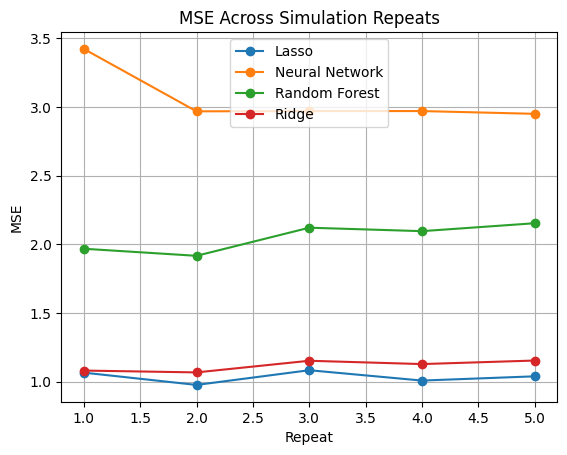

In [18]:
for model_name, group in mse_df.groupby("model"):
    plt.plot(
        group["repeat"],
        group["mse"],
        marker="o",
        label=model_name
    )

plt.xlabel("Repeat")
plt.ylabel("MSE")
plt.title("MSE Across Simulation Repeats")
#plt.yscale("log")
plt.legend()
plt.grid(True)
plt.show()



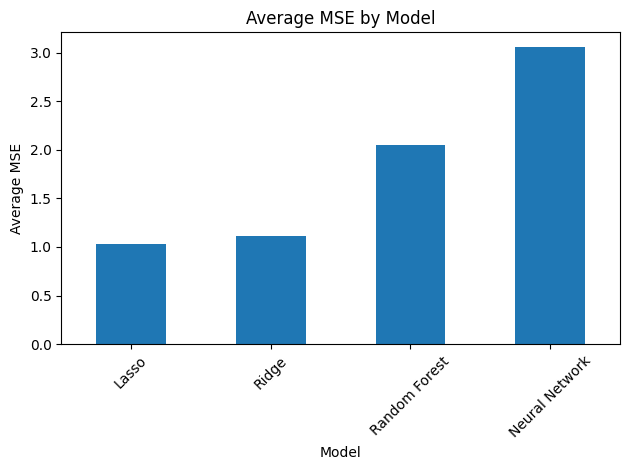

In [19]:
average_mse.plot(kind="bar")

plt.xlabel("Model")
plt.ylabel("Average MSE")
plt.title("Average MSE by Model")
#plt.yscale("log")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Conclusion 
Under the sparse signal setting with moderate correlation ((r = 0.3)) between (X_1) and (X_2), the overall model performance was similar to Experiment 01, where the predictors were independent. This suggests that moderate correlation did not substantially affect model performance in the current setting. However, different levels of correlation may lead to different results and should be investigated in future experiments.